# vRSA explained

Variational representation similarity analysis (vRSA) is a novel way to do Bayesian representational similarity analysis (RSA). It leverages the method known as pattern covariance modeling (PCM) to model the covariance matrix of multivariate (potentially time resolved) data as a linear combination of model matrices (matrices encoding particular contents of interests that might be represented in the data). It is a bit more involved than a traditional RSA, but that comes with quite a few benefits, such as being statistically optimal, unbiased by noise, and computationally efficient. 

In this notebook, we will explain how vRSA works for readers who do not have a strong mathematical background but are familiar with well-known statistical methods used in psychology and neuroscience. If you have knowledge of linear mixed models and have performed some multivariate data analysis in the past, but do not necessarily understand all the details (such as how the optimization happens in a linear mixed model), or if you have read the paper associated with this notebook and got a bit confused, this notebook is for you.

## Classical RSA

In a traditional RSA approach, researchers build trial by trial representational dissimilarity matrices by computing the correlation across channels between pairs of trials/experimental conditions. Say you have collected data in 2 conditions, say faces and objects, 10 trials each and 1 sample in each trial (in the case of an fMRI analysis for example). The resulting data are a matrix with 20 rows (10 faces trials, 10 objects trials) and as many columns as you have voxels/channels. In a RSA, the first step is to compute the correlation between all pairs of trials across channels, which tells you how similar the response patterns across channels is:

In [1]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle

A4_inches = [8.27-0.5,11.69-0.5]

design_matrix = np.squeeze(np.array([["face"] * 10 + ["object"] * 10]))
n_channels = 16
n_trials = design_matrix.shape[0]
data = np.random.normal(size=[n_trials, n_channels])


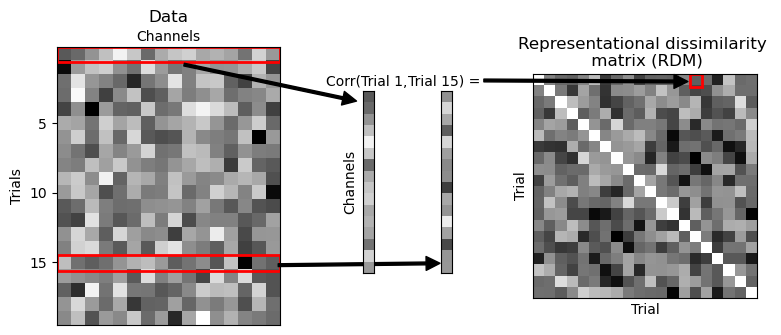

In [5]:
#| label: fig-rdm_computations
#| fig-cap: 'Illustration of representational dissimilarity matrix calculating in traditional RSA. '

vmin, vmax = np.min(data), np.max(data)
fig, ax = fig, ax = plt.subplot_mosaic("AABCDD", figsize=[A4_inches[0], 0.3*A4_inches[1]])
# Data:
ax["A"].imshow(data,cmap="Greys")
ax["A"].add_patch(Rectangle((-0.5, -0.5), n_channels, 1.1,
                        edgecolor='red', lw=2, fill=False))
ax["A"].add_patch(Rectangle((-0.5, 14.5), n_channels, 1.1,
                        edgecolor='red', lw=2, fill=False))
ax["A"].set_ylabel("Trials")
ax["A"].set_xlabel("Channels")
ax["A"].xaxis.set_label_position('top') 
ax["A"].set_yticks([5, 10, 15])
ax["A"].set_xticks([])
ax["A"].set_title("Data")

# Correlation:
ax["B"].imshow(data[0:1, :].T,cmap="Greys", vmin=vmin, vmax=vmax)
ax["C"].imshow(data[13:14, :].T,cmap="Greys", vmin=vmin, vmax=vmax)
ax["B"].set_xlabel("Corr(Trial 1, ")
ax["C"].set_xlabel("Trial 15) = ")
ax["B"].xaxis.set_label_position('top') 
ax["C"].xaxis.set_label_position('top') 
ax["B"].set_ylabel("Channels")
ax["B"].set_xticks([])
ax["C"].set_xticks([])
ax["B"].set_yticks([])
ax["C"].set_yticks([])

# Representation dissimilarity matrix:
rdm = np.zeros((n_trials, n_trials))
for i in range(n_trials):
    for ii in range(n_trials):
        rdm[i, ii] = 1 - pearsonr(data[i, :], data[ii, :]).correlation
ax["D"].imshow(rdm,cmap="Greys")
ax["D"].add_patch(Rectangle((13.5, -0.5), 1.1, 1.1,
                        edgecolor='red', lw=2, fill=False))
ax["D"].set_xlabel("Trial")
ax["D"].set_ylabel("Trial")
ax["D"].set_xticks([])
ax["D"].set_yticks([])
ax["D"].set_title("Representational dissimilarity \n matrix (RDM)")
plt.tight_layout()
#% Additional decorations:
plt.figure(1).ax_dict = {ax.get_label(): ax for ax in plt.figure(1).axes}
getattr(plt.figure(1), '_pylustrator_init', lambda: ...)()
plt.figure(1).ax_dict["A"].set(position=[0.08036, 0.04468, 0.2864, 0.8334])
plt.figure(1).ax_dict["A"].add_patch(mpl.patches.FancyArrowPatch((np.float64(-0.5), np.float64(19.5)), (np.float64(7.5), np.float64(9.5)), arrowstyle='Simple,head_length=10,head_width=10,tail_width=2', facecolor='black', clip_on=False, zorder=2))  # id=plt.figure(1).ax_dict["A"].patches[2].new
plt.figure(1).ax_dict["A"].patches[2].set_positions((np.float64(8.441406190716375), np.float64(0.7369455583410769)), (np.float64(21.23004517701594), np.float64(3.4413014203353747)))
plt.figure(1).ax_dict["A"].add_patch(mpl.patches.FancyArrowPatch((np.float64(-0.5), np.float64(19.5)), (np.float64(7.5), np.float64(9.5)), arrowstyle='Simple,head_length=10,head_width=10,tail_width=2', facecolor='black', clip_on=False, zorder=2))  # id=plt.figure(1).ax_dict["A"].patches[3].new
plt.figure(1).ax_dict["A"].patches[3].set_positions((np.float64(15.205371495610626), np.float64(15.200053554936897)), (np.float64(27.23595356085577), np.float64(15.059423538269298)))
plt.figure(1).ax_dict["B"].set(position=[0.4739, 0.2011, 0.0146, 0.5438])
plt.figure(1).ax_dict["C"].set(position=[0.574, 0.2011, 0.0146, 0.5438])
plt.figure(1).ax_dict["D"].set(position=[0.6933, 0.1268, 0.2874, 0.6692])
plt.figure(1).ax_dict["D"].add_patch(mpl.patches.FancyArrowPatch((np.float64(-0.5), np.float64(19.5)), (np.float64(9.5), np.float64(9.5)), arrowstyle='Simple,head_length=10,head_width=10,tail_width=2', facecolor='black', clip_on=False, zorder=2))  # id=plt.figure(1).ax_dict["D"].patches[1].new
plt.figure(1).ax_dict["D"].patches[1].set_positions((np.float64(-5.173617690395176), np.float64(0.055442448605223404)), (np.float64(13.596627852074), np.float64(0.15246851889019197)))
plt.show()

Each pixel in the representational dissimilarity matrix on the right is 1 minus the correlation across channels between each pairs of trials such that values that are closer to 0 indicate trials for which the responses across channels are more similar, and values that are closer to 1 indicate that the responses patterns across channels are not correlated. It doesn't have to be a Pearson correlation, there are many different metrics used to measured the similarity of the responses: Euclidean distance, Mahalanobis distance (see [here](https://www.sciencedirect.com/science/article/pii/S1053811918301411?casa_token=oitDL1ZKRc0AAAAA:VD4LJD8vkwQWm-8qJSxAFXdSpupk7b_CMmdlof1P2U1FRLc4iwcCjU4QvWCQfZjvZ4BGL6Hh_A)<sup>(1)</sup> for a discussion of these metrics). 

The idea is that if the brain region being investigated represents some information, in our case category, or at least the distinction between faces and objects, then the responses across channels should be more similar between two trials where a face was presented compared to when a face and an object were presented, and vice versa for objects. And to test whether and the extent to which a given information is represented, the representation dissimilarity matrix (RDM) that we calculated from the data can be related to model matrices (i.e. model RDM). For example, if we want to know if the data we have recorded represents the distinction between faces and objects, we can generate a model matrix representing that information:

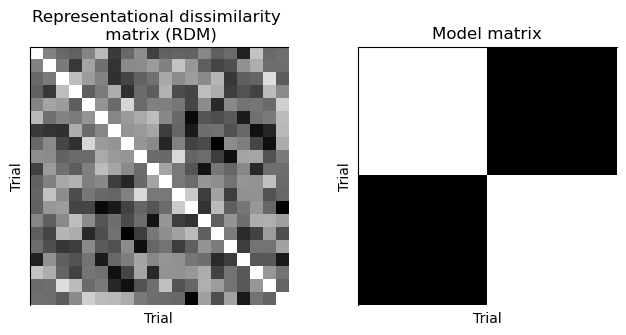

In [3]:
# Create model matrix for category representation
design_dummy = design_matrix.copy()
design_dummy[design_dummy == "face"] = 1
design_dummy[design_dummy == "object"] = -1
design_dummy = design_dummy.astype(int).reshape(-1, 1)
model_matrix = 1 - (design_dummy @ design_dummy.T)

# Plot the two matrices:
fig, ax = fig, ax = plt.subplot_mosaic("AB", figsize=[A4_inches[0], 0.3*A4_inches[1]])
# Observed RDM
ax["A"].imshow(rdm,cmap="Greys")
ax["A"].set_xlabel("Trial")
ax["A"].set_ylabel("Trial")
ax["A"].set_xticks([])
ax["A"].set_yticks([])
ax["A"].spines[['right', 'bottom']].set_visible(False)
ax["A"].set_title("Representational dissimilarity \n matrix (RDM)")
# Model matrix:
ax["B"].imshow(model_matrix,cmap="Greys")
ax["B"].set_xlabel("Trial")
ax["B"].set_ylabel("Trial")
ax["B"].set_xticks([])
ax["B"].set_yticks([])
ax["B"].spines[['right', 'bottom']].set_visible(False)
ax["B"].set_title("Model matrix");

The correlation between the observed RDM and the model matrices can be computed, and if the two are significantly correlated, one can infer that the brain does represent the category distinction between faces and objects at the "mutlivariate level", i.e. in terms of the patterns across channels. 

## Pattern component modeling
While the RSA approach describe above is quite straight forward, it suffers from an important shortcoming. The aim of the first step, i.e. computing the correlation between pairs of trials across channels, is to characterize the similarity of the responses across channels. The problem is that when computing the correlation based on the raw data, the estimate of the similarity between responses is biased by noise. In fact, when doing:

$$
RDM_{trial_1, trial_2} = corr(y_{trial_1}, y_{trial_2})
$$

What we get is:

$$
corr(\hat{y}_{trial_1}, \hat{y}_{trial_1}) = corr(y_{trial_1}, y_{trial_2}) + corr(\epsilon_{trial_1}, \epsilon_{trial_2})
$$

This leads to significant bias in the estimation of the similarity between pairs of trials, meaning that the estimated similarity will change depending on whether there is a lot of noise or not. The technique of pattern component modeling (PCM) was introduced by Diedrichsen and colleagues [2011](https://www.sciencedirect.com/science/article/pii/S1053811911000796)<sup>(2)</sup> to address exactly that issue. In their paper, they use simulation to show the problem:

![Correlation noise sensitity: (B) Each figure represents the measured correlation between two activation patterns across channels simulated with known correlation of 0 (left), -0.2 (middle) and 0.8 (right). Y axis represents sample correlation (grey line) or component model (black line). Taken from @diedrichsen2011comparing](../assets/correlation_noise_sensitivity.png){#fig-correlation_noise_sensitivity fig-alt="Correlation noise sensivity"}

To generate this figure, the authors simulated activation patterns across channels in two different trials, with know correlation, and they modulated the amount of noise in the simulated data. The figure on the left shows how the measured correlation changes when noise increase, when the data where simulated without any correlation. Since the data were simulated without any correlation, the measured correlation (called sample correlation in the figure) should be 0, which we can see that it is. As noise increases, the measured correlation remains at 0, as we would expect. But now, when we look at the figure in the center, where the correlation between the two channels is -0.2 (which we know because the data were simulated), we can see that as noise increases, the sample correlation comes closer to 0. Similarly, on the right graph, where the correlation is 0.8, the sample correlation goes down towards 0 as noise increases.

The way the PCM method deals with this is by modelling both the noise and the covariance between pairs of trials across channels instead of directly taking the correlation between pairs of vectors of channels/voxels activation. The way it does so is based on linear mixed models, which we will now briefly introduce. 

## Linear mixed models
Linear mixed models, also know as hierarchical models in the Bayesian world, is an extension of the linear model, typically used to analyze nested data. It is particularly popular in psychology and cognitive neuroscience, in which within subject designs are common place. In such designs, an each experimental condition is repeated multiple times is repeated across multiple subject. In order to account for the nested nature of the data, a linear mixed model fits the data in a hierarchical way, by estimating the regression coefficients for each of the subjects, and then looking at the distribution of the estimates across subjects to infer the population level of the parameter of interest. It is written mathematically like so:

$$
y = X\beta + ZU + e
$$

You have most likely heard the following way of describing linear mixed model: "a linear mixed model enables to fit fixed and random effects. The fixed effects are the effects we care about, and the random effects are the effects we don't care about". In our faces vs. objects example from above, say we have recorded the data in 20 subjects want to know how much larger activation is when a face is presented compared to an object in a particular brain region. We don't really care about what's the specific value in each subject, because if we had had a different set of subjects, the values would have been different. What we care about is the fixed effect, i.e. overall, across the random sample that we have, what is the population estimate. 

This way of explaining the distinction between fixed and random effect is a bit misleading. In reality, it is not so much that the fixed effects are "what we care about" and that the random effects are what we "don't care about". It's more that what we care about for the fixed effect is different from what we care about for the random effects. For the fixed effects, what we care about are the mean parameter estimates, i.e. our estimates of the $\beta$ parameters, while for the random effects, what we care about is the variance and covariance of these effects. Reflecting this distinction, a linear mixed model estimates something different for the fixed compared to the random effects. Specifically:

$$
\beta \sim \mathcal{N}(\mu, \sigma^2)
$$

And

$$
U \sim \mathcal{N}(0, G)
$$

That is, the fixed effects are modelled as variables with unknown mean and standard error. On the other hand, the random effects are modelled as being centered on 0, with unknown covariance $G$.


### Concrete example:
To make this more concrete, let's take our example of faces vs. objects. Say we have the hypothesis that activation in the fusiform face area (brain region known to be responsive to faces) is larger when a face stimulus is presented compared to when an object is presented, and we have conducted the previously described experiment on 20 subjects. We can model the neural activity in this particular brain region using a linear mixed model:

$$
y = X\beta + ZU + e
$$

Where $X$ contains the fixed effects: an intercept term, and the effect of category. $Z$ contains the random effects: the within subject intercept, and the within subject effect of category. We can write this in a format that might be more familiar to those used to the lme4 syntax:

$$
y \sim 1 + Category + (1 + Category|Subject)
$$

To answer our question, we would typically look at the fixed effect: if we find an effect of our category regressor, that would mean that on average, across participants, the responses differ between faces and objects. Furthermore, the sign of the effect tell us which of the two conditions elicit a larger response: a positive effect could indicate that the faces elicit a stronger response (depending on how exactly the category regressor was encoded). 

At the same time, for such a question, we don't really care about what the exact difference between faces and objects is for each subject, because we would assume that if we ran the same experiment on different subjects, the exact values would be different, though the average across subjects would remain the same. This is why we don't care about the mean values for the random effect. In fact, we actually assume that across subjects, the mean of the random effect will be 0. That is because the random effect characterize how much the effect within each subject differs from the population mean (i.e. from the fixed effect), and we would assume that to be centered on zero because some participants will have a bit stronger or a bit weaker effects, averaging out to 0. 

However, with the random effect, what we might very well care about is the covariance matrix. Remember that the random effects are modeled as $U \sim \mathcal{N}(0, G)$, and G is the covariance of the random effects. This covariance matrix characterizes the covariance between the random effects. What does that mean? In our example, we have two random effects: the intercept, and the category. Calcuating the covariance between these two consists in computing how the strength of the intercept and of the category effect are related across participants. That is, it is answering the question: "do participants that have large intercepts (i.e. large mean activation) tend to have strong differences between faces and objects or not?". Positive values means that the participants that have strong activation across categories have the stronger differences between faces and objects. Negative values means that participants that have strong activation have small differences, and 0 means no relationship. For our problem, the covariance matrix is the following:

$$
G = 
\begin{bmatrix}
\sigma_{Intercept}^2  &  Cov(Intercept, Category) \\
Cov(Intercept, Category) & \sigma_{Category}^2 
\end{bmatrix}
$$

The diagonal represents the variance across subject of each of the effects, i.e. how much variance there is in mean activation and category effects across subjects, whereas the off-diagonal represents the covariance between these two effects as we have explained.

Hopefully, this clarifies the misconception of the fixed effects being the effects we care about and the random effects being the effects we don't care about. In truth, the fixed effects are the effects for which we are interested in the mean parameters, whereas for the random effects, we are not interested in the mean of the parameters but rather in their variance and covariance. In our example, we are not interested at the mean value of each subject, cause if we had a different sample, we would expect these values to be different. But we are (or at least might be) interested in the variance across participants as well as the covariance across subjects. And in fact, even if we are not interested in the random effects at all, it is necessary to model them in those terms (variance and covariance), to make sure we get reliable estimates for our fixed effects. 

## Link between Pattern component modeling and linear mixed models

To put it simply, the core idea of PCM is to estimate the similarity of the responses across channels by modelling it as the covariance matrix of the random effects of a linear mixed model. In our example above, we consider the case where we are repeating the same experiment across many subjects, such that the covariance matrix of the random effects characterizes the covariance between effects of interests. The bey idea behind PCM is to consider the channels as repeated samples in the same way, and model it as the random effects of the model. Let's again illustrate it with the same example as above:

$$
\mathbf{Y} \sim 1 + (1 + Category|channel)
$$

In that case, $\mathbf{Y}$ is not the response across subjects, but across all the voxels within the fusiform face area for example. Now, when we compute the covariance matrix, we get the same as above:

$$
G = 
\begin{bmatrix}
\sigma_{Intercept}^2  &  Cov(Intercept, Category) \\
Cov(Intercept, Category) & \sigma_{Category}^2 
\end{bmatrix}
$$

This is a very similar idea to the representational dissimilarity matrix. We can make it even more like it if instead of having a category regressor, we instead have a single trial number regressor and remove the intercept:

$$
\mathbf{Y} \sim 1 + (Trial|channel)
$$


$$
G = 
\begin{bmatrix}
\sigma_{trial 1}^2  &  Cov(trial 1, trial 2) & \dots & Cov(trial 1, trial N) \\
Cov(trial 2, trial 1) & \sigma_{trial 2}^2 & \dots & Cov(trial 2, trial N) \\
\vdots & \vdots & \ddots & \dots \\
Cov(trial N, trial 1) & Cov(trial N, trial 2) & \dots & \sigma_{trial N}^2  \\
\end{bmatrix}
$$

To reiterate: PCM consists in estimating response patterns as variance covariance matrix by treating these as random effects. There is one slight distinction compared to the typical linear mixed model: in the case of PCM, a multivariate linear mixed model is used, which is why the data are depicted using capital $\mathbf{Y}$ means that $Y$ is not a vector but a matrix. That doesn't change anything to the explanation of the concept presented here.

And why is estimating the response patterns in this convolved way better than directly calculating the correlation between pairs of trials across channels/voxels? It's because as part of the estimation of the covariance of the random effects, the noise is taken into account. Indeed, in the linear mixed model framework, the data are modelled as:

$$
\mathbf{Y} = \mathbf{X}\beta + \mathbf{Z}\mathbf{U} + \mathbf{\epsilon}
$$

Where:

$$
\beta \sim \mathcal{N}(\mu, \sigma^2)
$$

$$
\mathbf{U} \sim \mathcal{N}(0, G)
$$

$$
\mathbf{\epsilon} \sim \mathcal{N}(0, I\sigma_{\mathbf{\epsilon}}^2)
$$

When estimating the sample correlation directly, the calculcated values are sensitive to noise (as we can see in @fig-correlation_noise_sensitivity). With the PCM approach, noise is separated out from the covariance matrix in the estimation process, leading to unbiased estimates. 

An added bonus of the PCM approach is that it enables to take into account nuisance effects that might contaminate the covariance matrix. It is important here not to mix up nuisance effects and random effects! In this context, nuisance effects are effects that might be present in the observed covariance of the data but that we are not interested in. In other words, here nuisance effects are effects that might contaminate the computation of random effects. Such effects could be temporal drift for example, but it could also be a fixed effect for which we are not interested in the covariance structure and we in fact want to evaluate the covariance of the data independently of this effect. In fact, as part of the estimation of the covariance structure of the random effect, the fixed effects are orthogonalized through projection, which means that the covariance for the random effect is not contaminated by the fixed effects (more on this in the explanation of how spm_reml_sc.m works). 

## Pattern component modelling and vRSA

As such, the PCM method only yields an unbiased estimate of the covariance structure of the data. If implemented in a trial by trial fashion, it can give reliable estimates of how similar the responses are between pairs of trials. This is however only step 1 in an RSA pipeline, because then we typically want to know whether there is some information related to important experimental manipulation in this covariance matrix. The way this is done in traditional RSA is by correlating the observed RDM with a model matrix operationalizing a particular feature we are interested in testing. If there are more features we are interested in testing, we would do these correlations one by one. 

In contrast, the approach taken in vRSA is very similar to the PCM approach. In PCM, the patterns similarity is measured as the covariance matrix of random effects, yielding one covariance value for each pairs of trials. In the case of vRSA, the approach is the same, but instead of estimating the covariance of each pairs of trials, the entire covariance matrix of the random effects is itself modelled as a linear mixture of model matrices:

$$
G = \sum_{n=1}^k v_n Q_n
$$

$G$ is the covariance matrix of the random effects, $Q_n$ is a model matrix, and $v_n$ is the weight of this particular model matrix. In vRSA, instead of trying to find the overall covariance matrix $G$ that fits the data the best, we are trying to find the values $v$ for each of the model matrices we are interested in. Let's vizualize the idea, taking an hypothetical experiment where we present faces and objects, but this time in two different attention condition (attended vs. inattended):

Text(0.636, 0.7761, '+')

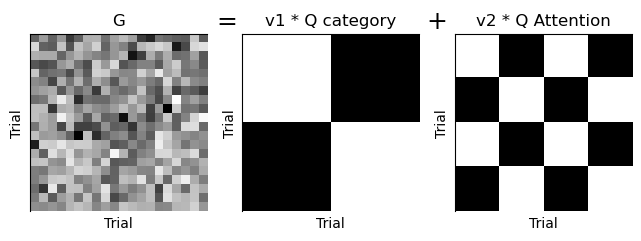

In [ ]:
# Define design matrix:
design_matrix = np.squeeze(np.array(
    [["face"] * 10 + ["object"] * 10, 
    ["attended"] * 5 + ["unattended"] * 5 + ["attended"] * 5 + ["unattended"] * 5]))
# Dummy code the design matrix:
design_dummy = design_matrix.copy()
design_dummy[design_dummy == "face"] = 1
design_dummy[design_dummy == "object"] = -1
design_dummy[design_dummy == "attended"] = 1
design_dummy[design_dummy == "unattended"] = -1
design_dummy = design_dummy.astype(int)

# Create the model matrices associated with category and attention conditions:
Q_category = 1 - np.outer(design_dummy[0, :].T, design_dummy[0, :])
Q_attention = 1 - np.outer(design_dummy[1, :].T, design_dummy[1, :])

# Create a random G matrix:
G = np.random.normal(size=[n_trials, n_trials])

# Plot example:
fig, ax = fig, ax = plt.subplot_mosaic("ABC", figsize=[A4_inches[0], 0.3*A4_inches[1]])
# Plot G:
ax["A"].imshow(G,cmap="Greys")
ax["A"].set_xlabel("Trial")
ax["A"].set_ylabel("Trial")
ax["A"].set_xticks([])
ax["A"].set_yticks([])
ax["A"].spines[['right', 'bottom']].set_visible(False)
ax["A"].set_title("G")

# Plot Q category:
ax["B"].imshow(Q_category,cmap="Greys")
ax["B"].set_xlabel("Trial")
ax["B"].set_ylabel("Trial")
ax["B"].set_xticks([])
ax["B"].set_yticks([])
ax["B"].spines[['right', 'bottom']].set_visible(False)
ax["B"].set_title("v1 * Q category")

# Plot Q attention:
ax["C"].imshow(Q_attention,cmap="Greys")
ax["C"].set_xlabel("Trial")
ax["C"].set_ylabel("Trial")
ax["C"].set_xticks([])
ax["C"].set_yticks([])
ax["C"].spines[['right', 'bottom']].set_visible(False)
ax["C"].set_title("v2 * Q Attention")

# Add decoration:
plt.figure(1).ax_dict = {ax.get_label(): ax for ax in plt.figure(1).axes}
getattr(plt.figure(1), '_pylustrator_init', lambda: ...)()
plt.figure(1).text(0.3657, 0.7761, '=', transform=plt.figure(1).transFigure, fontsize=18.)  # id=plt.figure(1).texts[0].new
plt.figure(1).text(0.6360, 0.7761, '+', transform=plt.figure(1).transFigure, fontsize=18.);  # id=plt.figure(1).texts[1].new

With vRSA, we can answer the same question as with RSA. If we want to know whether category is represented in a given brain region, we can look at the $v_1$ parameter: if it is significantly different from 0, we have evidence that indeed this specific model component is represented in our data. One of the advantages is that we are not limited to one component at a time, rather we can investigate several effects at the same time, making the procedure more statistically efficient compared to RSA which requires fitting as many separate correlations as model matrices we want to test. 

One important detail is that when the model is fitted, we do not directly estimate $v$, but $\lambda$ instead, which is the log of $v$. The reason for this is that we want to make sure that all $v_n$ are positive, as a negative covariance matrix isn't possible (covariance has to be positive definite).  

The way these $v$ parameters are estimated are based on restricted maximal likelihood. Importantly, the parameters are identified using approximate Bayesian inference, specifically variational inference, which basically means that the parameters are approximated using advanced calculus. This will be discussed in the next notebook where we will actually explain in detail how these parmaters are estimated using spm_reml_sc.m. 

## Conclusion

This concludes our conceptual explanation of vRSA. PCM treats the response patterns (i.e. activation across channels in a particular trial) as random effects of a linear mixed model to obtain unbiased estimates of the similarity of the responses, which is an improvement over the traditional approach of RSA where the measures of responses similarity are contaminated by noise. The vRSA is following the same idea, but instead of estimating the covariance matrix itself, it is modelling it as a combination of model matrices for which the weights $v_n$ are estimated. This approach has a lot of advantages compared to traditional RSA, as we discussed in the paper these notebooks accompany. Hopefully, this has provided a useful conceptual explanation of the various concepts we call upon in the paper, while still being approachable to readers that do not have a strong background in mathematics. 

## References
(1) Guggenmos, M., Sterzer, P., & Cichy, R. M. (2018). Multivariate pattern analysis for MEG: A comparison of dissimilarity measures. Neuroimage, 173, 434-447.
(2) Diedrichsen, J., Ridgway, G. R., Friston, K. J., & Wiestler, T. (2011). Comparing the similarity and spatial structure of neural representations: a pattern-component model. Neuroimage, 55(4), 1665-1678.